# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [ ]:
#I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material. Gigi Flores.

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [9]:
#g is in units of meters/sec^2, and l has units of meters
g = 9.81
l = 1

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [11]:
def pendulum(t, y):
    #both theta and omega are contained within the variable y, so differentiating them results in the following way
    theta, omega = y
    dtheta_dt = omega
    domega_dt = -(g / l) * np.sin(theta)
    return [dtheta_dt, domega_dt]

Give you equation some initial conditions. Run the cell below.

In [13]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

#assigning the given initial conditions 
init_conditions = [theta_0, omega_0]

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [15]:
#setting the simulation time and evaluation time
sim_time = 10
eval_time = np.linspace(0, sim_time, 10)

#solve_ivp takes in parameters of our pendulum (differential equation), the interval of integration, initial conditions, and the evaluation time
sol = solve_ivp(pendulum, [0, sim_time], init_conditions, t_eval=eval_time)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [17]:
theta_values = sol.y[0]
time_values = sol.t

#printing theta and time values of our solution
print("Theta Values: " + str(theta_values))
print("Time Values: " + str(time_values))

Theta Values: [ 0.17453293 -0.16502944  0.1372768  -0.09451914  0.04132961  0.01640821
 -0.07231679  0.12026021 -0.15495771  0.17260154]
Time Values: [ 0.          1.11111111  2.22222222  3.33333333  4.44444444  5.55555556
  6.66666667  7.77777778  8.88888889 10.        ]


Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [19]:
theoretical_period = 2 * np.pi * np.sqrt(l / g)

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [21]:
#np.round takes in the number, and the 2 represents the decimal points
print(np.round(theoretical_period, 2))

2.01


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [28]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

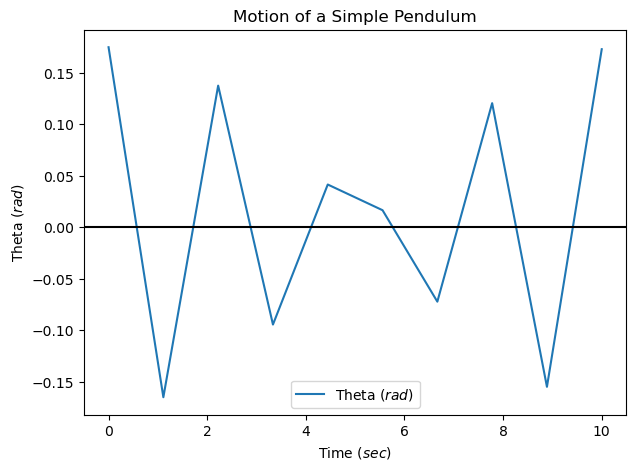

In [23]:
#creating the figure and plotting theta values vs time values
plt.figure(figsize=(7, 5))
plt.plot(time_values, theta_values, label="Theta $(rad)$")
plt.axhline(0, color="black")

#labeling the plot
plt.xlabel("Time $(sec)$")
plt.ylabel("Theta $(rad)$")
plt.title("Motion of a Simple Pendulum")
plt.legend()

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [30]:
print(np.round(T_numerical, 4))

2.2222


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

The approximation matches the numerical result well. The small angle approximation resulted in a period that was 2.01 sec, which is definitely close to the numerical calculation which resulted in a value of 2.22. These values are not as close as they could be since the small angle approximation fails when the simple pendulum rises to angles that are greater than the assumption we take for small angles. As such, while they are close, there are reasons that explain the difference of about 0.2.

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [34]:
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [ ]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [38]:
#loading the dataset into the df dataframe
df = pd.read_csv("owid-covid-data.csv")

hello


Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [40]:
#creates a new dataframe with only the data relating to the United States
df_country = df[df['location'] == 'United States']

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In [46]:
#from the data in the United States, we only look at the two columns "date" and "total_cases", while .dropna() drops the rest of the columns
df_country = df_country[['date', 'total_cases']].dropna()

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [48]:
df_country["days since start"] = range(len(df_country))

Print the first few rows of your `df_country` dataframe.

In [52]:
#.head() prints the first few rows of our dataframe
print(df_country.head())

              date  total_cases  days since start
403451  2020-01-05          0.0                 0
403452  2020-01-06          0.0                 1
403453  2020-01-07          0.0                 2
403454  2020-01-08          0.0                 3
403455  2020-01-09          0.0                 4


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [68]:
from scipy.optimize import curve_fit
import numpy as np

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [133]:
#this function models the exponential growth model above
def exponential_growth(t, C_0, r):
    C_t = C_0 * np.exp(r * t)
    return C_t

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [72]:
#[:30] indexes through the first 30 rows of the dataframe
days = df_country["days since start"][:30]
cases = df_country["total_cases"][:30]

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [74]:
#curve_fit has our parameters of a function (exponential_growth), and takes in our two variables to curve fit, with the argument p0
popt, pcov = curve_fit(exponential_growth, days, cases, p0=[1, 0.1])

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [110]:
#assigning our two best fit parameters from popt to the variables C0_fit and r_fit
[C0_fit, r_fit] = popt

#while the question doesn't ask for this, this line of code prints the errors associated with the best fit parameters, which is helpful in analyzing how well the exponential model fits the data.
std_errs = np.sqrt(np.diag(pcov))
print(np.transpose([popt, std_errs]))

[[0.12389531 0.07718632]
 [0.15384247 0.02356906]]


Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [78]:
print(np.round(C0_fit, 2))
print(np.round(r_fit, 4))

0.12
0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [84]:
#np.arange starts at 0, and does not include the endpoint. therefore to print 60 days, we go up to 61. 
future_days = np.arange(0, 61)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [90]:
#predicted cases will be the numerical values predicted by our exponential growth model
predicted_cases = exponential_growth(future_days, *popt)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

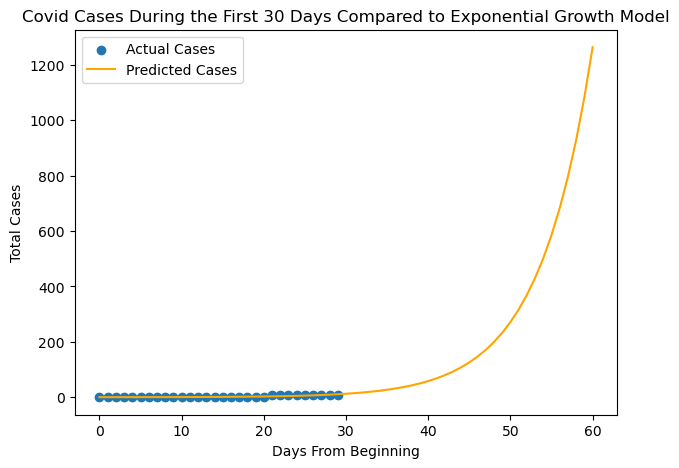

In [106]:
#creating the figure and plotting the scatterplot and exponential growth model
plt.figure(figsize=(7, 5))
plt.scatter(days, cases, label="Actual Cases")
plt.plot(future_days, predicted_cases, color="orange", label="Predicted Cases")

#labeling the plot
plt.xlabel("Days From Beginning")
plt.ylabel("Total Cases")
plt.title("Covid Cases During the First 30 Days Compared to Exponential Growth Model")
plt.legend()

How well does your exponential model fit the actual COVID-19 data? 

The data fits the model extremely well so far. Every data point representing the actual cases is on the exponential growth model, indicating that it is a good fit for the data. From above, we see that our best fit parameters are C_0 = 0.12 +- 0.077 and r = 0.1538 +- 0.0235. The low errors on the best fit parameters indicate that our data does not deviate away from the exponential growth model, meaning that it provides a really good fit for the COVID-19 data. However, it should be noted that we only plotted the first 30 days, and as such it would be important to analyze the trend as the number of days is larger.

Make another plot but this time to **90 days**.

[[0.1347851  0.12293684]
 [0.15707077 0.01056616]]
Best Fit Parameters: C_0 = 0.13 +- 0.1229, r = 0.1571 +- 0.0106


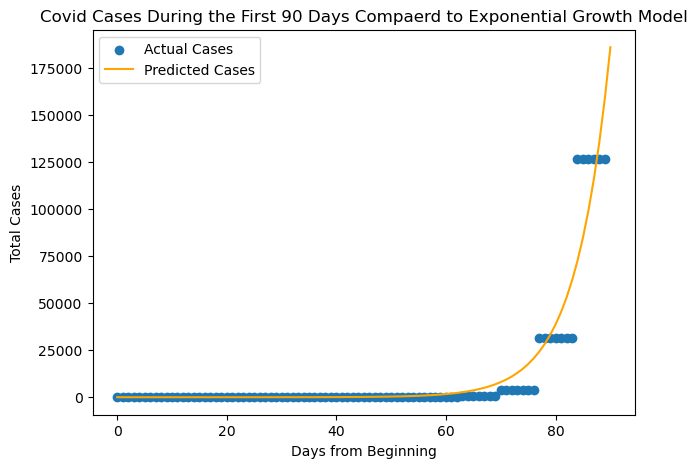

In [149]:
#the following code changes days and cases to go up to the first 90 rows, instead of 30 to see if it matches the exponential growth model.
days_updated = df_country["days since start"][:90]
cases_updated = df_country["total_cases"][:90]

#re-curve fitting on the updated days and cases
popt_updated, pcov_updated = curve_fit(exponential_growth, days_updated, cases_updated, p0=[1, 0.1])
[C0_fit_updated, r_fit_updated] = popt_updated

#printing the new best fit parameters with their associated errors
std_errs_updated = np.sqrt(np.diag(pcov_updated))
print(np.transpose([popt_updated, std_errs_updated]))

#creating the predicted data up to 90 days
future_days_updated = np.arange(0, 91)
predicted_cases_updated = exponential_growth(future_days_updated, *popt_updated)

#creating the figure and plotting the data
plt.figure(figsize=(7, 5))
plt.scatter(days_updated, cases_updated, label="Actual Cases")
plt.plot(future_days_updated, predicted_cases_updated, color="orange", label="Predicted Cases")

#labeling the plot
plt.xlabel("Days from Beginning")
plt.ylabel("Total Cases")
plt.title("Covid Cases During the First 90 Days Compaerd to Exponential Growth Model")
plt.legend()
print("Best Fit Parameters: C_0 = 0.13 +- 0.1229, r = 0.1571 +- 0.0106")

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [159]:
predicted_cases_day_87 = exponential_growth(87, *popt_updated)
print("The predicted number of COVID cases on day 87 is " + str(np.round(predicted_cases_day_87, 2)) + ".")

The predicted number of COVID cases on day 87 is 115969.56.


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

[[ 5.01532658e+01  1.54023098e+00]
 [-5.87209266e+03  3.10285153e+02]]


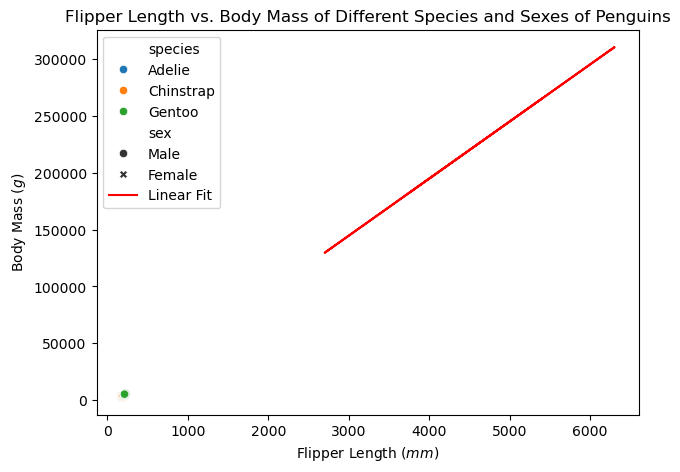

In [189]:
import seaborn as sns

#getting the dataset and putting it under the variable penguins
penguins = sns.load_dataset("penguins")

#creating the figure and plotting the data. 
#for the scatterplot, we want x and y to be the numerical data comparing flipper length to body mass. 
#furthermore, this data gets sorted based on hue which changes the colors depending on the species of penguin, and the style of the point gets changed based on the sex of the penguin.
plt.figure(figsize=(7, 5))
sns.scatterplot(data = penguins, x=  "flipper_length_mm", y = "body_mass_g", hue = "species", style = "sex")
plt.xlabel("Flipper Length $(mm)$")
plt.ylabel("Body Mass $(g)$")
plt.title("Flipper Length vs. Body Mass of Different Species and Sexes of Penguins")

#after looking at the data, a linear model would fit the data well
def linear_model(x, m, b):
    y = m * x + b
    return y

#extracting flipper length and body mass data from penguins dataset 
flipper = penguins.dropna()["flipper_length_mm"]
bodymass = penguins.dropna()["body_mass_g"]

#curve fitting, extracting best fit parameters, and calculating errors
popt_penguins, pcov_penguins = curve_fit(linear_model, flipper, bodymass, p0=[1, 1])
[m, b] = popt_penguins
std_errs_penguins = np.sqrt(np.diag(pcov_penguins))
print(np.transpose([popt_penguins, std_errs_penguins]))

#calculating predicted flipper length based off of body mass
predicted_body_mass = linear_model(flipper, *popt_penguins)

plt.plot(flipper, predicted_flipper_length, color="red", label="Linear Fit")
plt.legend()

On it's own branch, submit this notebook to Gradescope! 